# 8. 고급 인과추론 머신러닝

이 노트북은 단순한 평균 처치 효과(ATE) 계산을 넘어, 더욱 복잡하고 현실적인 상황에 적용할 수 있는 고급 인과추론 머신러닝 기법들을 다룬다.

1.  **이중 강건성 방법론 (Doubly Robust Methods)** 

2.  **이중 머신러닝 (Double Machine Learning, DML)**:  
3.  **표적 최대 가능도 추정법 (Targeted Maximum Likelihood Estimator, TMLE)**: 

4.  **인과 포레스트 (Causal Forests)**: 

5.  **실험 데이터를 이용한 이질적 처치 효과 (HTE) 분석**: 

6.  **반사실적 설명 (Counterfactual Explanations)**: 

In [1]:
from copy import deepcopy
import json
import time

import pandas as pd
import numpy as np
import pandas as pd
from scipy import stats

import dowhy
from dowhy import CausalModel
from econml.metalearners import SLearner, XLearner, TLearner
from econml.dml import LinearDML, CausalForestDML, DML
from econml.dr import DRLearner, SparseLinearDRLearner

from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor, LGBMClassifier

import networkx as nx
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import graphviz

In [2]:
COLORS = [
    '#00B0F0',
    '#FF0000',
    '#B0F000'
]

## **1. 이중 강건성 방법론 (Doubly Robust Methods)**

In [3]:
def plot_effect(effect_true, effect_pred, figsize=(10, 7), ylim=(5000, 22000)):
    plt.figure(figsize=figsize)
    plt.scatter(effect_true, effect_pred, color=COLORS[0])
    plt.plot(np.sort(effect_true), np.sort(effect_true), color=COLORS[1], alpha=.7, label='Perfect model')
    plt.xlabel('$True\\ effect$', fontsize=14, alpha=.5)
    plt.ylabel('$Predicted\\ effect$', fontsize=14, alpha=.5)
    plt.ylim(ylim[0], ylim[1])
    plt.legend()
    plt.show()

### **1.1 데이터 불러오기**

In [4]:
# Train set
earnings_interaction_train = pd.read_csv('./data/ml_earnings_interaction_train.csv')

# Test set
earnings_interaction_test = pd.read_csv('./data/ml_earnings_interaction_test.csv')

In [5]:
earnings_interaction_train.shape, earnings_interaction_test.shape

In [6]:
# Train
earnings_interaction_train.head()

,age,python_proficiency,took_a_course,earnings
0,23,0.632318,True,139267.0
1,20,0.602551,False,115569.0
2,21,0.518225,False,119142.0
3,25,0.945161,False,130291.0
4,30,0.636251,True,164209.0


In [7]:
# Test
earnings_interaction_test.head()

,age,python_proficiency,took_a_course,true_effect
0,30,0.223877,True,11120.0
1,23,0.394152,True,11970.0
2,37,0.214638,True,11073.0
3,21,0.869069,True,14345.0
4,41,0.833934,True,14169.0




### **1.2 인과 그래프 정의**

In [8]:
# Construct the graph (the graph is constant for all iterations)
nodes = ['took_a_course', 'python_proficiency', 'earnings', 'age']
edges = [
    ('took_a_course', 'earnings'),
    ('age', 'took_a_course'),
    ('age', 'earnings'),
    ('python_proficiency', 'earnings')
]

# Generate the GML graph
gml_string = 'graph [directed 1\n'

for node in nodes:
    gml_string += f'\tnode [id "{node}" label "{node}"]\n'

for edge in edges:
    gml_string += f'\tedge [source "{edge[0]}" target "{edge[1]}"]\n'

gml_string += ']'

In [9]:
# Instantiate the CausalModel
model = CausalModel(
    data=earnings_interaction_train,
    treatment='took_a_course',
    outcome='earnings',
    effect_modifiers='python_proficiency',
    graph=gml_string
)

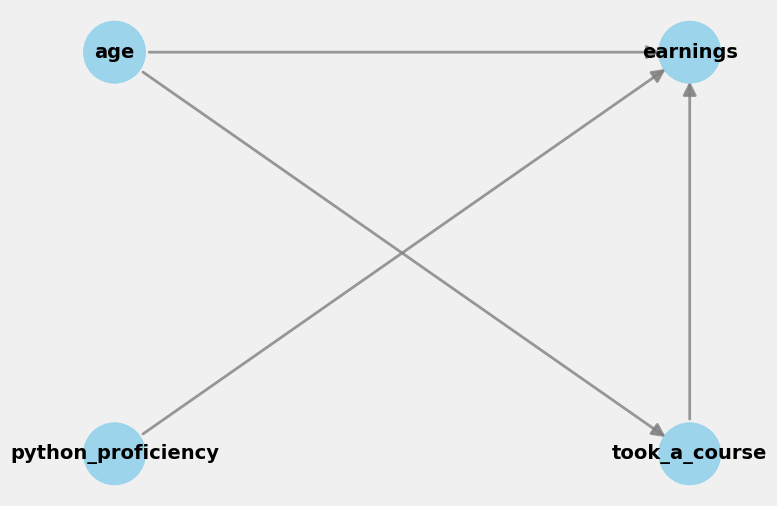

In [10]:
model.view_model()




### **1.3 추정량(Estimand) 식별**

In [11]:
# Get the estimand
estimand = model.identify_effect()

print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                         
────────────────(E[earnings|age])
d[took_a_course]                 
Estimand assumption 1, Unconfoundedness: If U→{took_a_course} and U→earnings then P(earnings|took_a_course,age,U) = P(earnings|took_a_course,age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!




`CausalModel` 객체의 `identify_effect` 메서드를 사용하여 인과 효과 추정을 위한 통계적 표현, 즉 추정량(estimand)을 식별한다. `dowhy`는 정의된 인과 그래프를 분석하여 여러 식별 전략(후문, 전문, 도구 변수 등)을 탐색한다. 실행 결과, 'backdoor' (후문) 기준을 만족하는 추정량이 식별되었으며, 이는 'age' 변수를 통제(보정)함으로써 'took\_a\_course'가 'earnings'에 미치는 인과 효과를 추정할 수 있음을 의미한다. 또한, 이 추정이 유효하기 위한 핵심 가정인 비혼란성(Unconfoundedness) 가정도 명시되어 있다.

### **1.4 인과 효과 추정**

In [12]:
# Get estimate (Doubly robust)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dr.LinearDRLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'model_propensity': LogisticRegression(),
            'model_regression': LGBMRegressor(n_estimators=1000, max_depth=10)
        },
        'fit_params': {}
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 289
[LightGBM] [Info] Number of data points in the train set: 2500, number of used features: 3
[LightGBM] [Info] Start training from score 143531.830000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

식별된 추정량을 바탕으로 `estimate_effect` 메서드를 사용하여 실제 인과 효과를 추정한다. `method_name`으로 `'backdoor.econml.dr.LinearDRLearner'`를 지정하여, `EconML` 라이브러리에서 제공하는 이중 강건성(Doubly Robust) 선형 학습자를 사용한다.

이 방법론의 핵심 이론은 두 개의 보조 모델(nuisance model)을 사용하는 것이다.

1.  **성향 점수 모델 (`model_propensity`):** 처치를 받을 확률을 예측하며, 여기서는 `LogisticRegression`을 사용한다.
2.  **결과 모델 (`model_regression`):** 처치와 공변량이 주어졌을 때의 결과값을 예측하며, `LGBMRegressor`를 사용한다.

`LinearDRLearner`는 이 두 모델의 예측 오차(잔차)를 사용하여 최종적으로 처치 효과를 선형적으로 추정한다. 이 접근법은 성향 점수 모델이나 결과 모델 둘 중 하나만 올바르게 명시되어도 일관된 추정치를 제공하는 이중 강건성 속성을 가진다. `target_units`를 'ate'로 설정하여 평균 처치 효과(Average Treatment Effect)를 목표로 한다.

In [13]:
estimate.cate_estimates.mean()


앞서 `LinearDRLearner`로 추정한 개별 처치 효과(CATE, Conditional Average Treatment Effect) 값들의 평균을 계산하여 평균 처치 효과(ATE, Average Treatment Effect)를 구한다. 이는 강의를 수강하는 것이 수입에 평균적으로 약 12572.17만큼의 긍정적인 효과를 가짐을 의미한다.


In [14]:
# Compute predictions
effect_pred = estimate.estimator.effect(
    earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1)
)

# Get the true effect
effect_true = earnings_interaction_test['true_effect'].values

학습된 추정기(`estimator`)를 사용하여 테스트 데이터셋(`X_test`)에 대한 개별 인과 효과를 예측한다. 예측에 불필요한 'true\_effect'와 처치 변수인 'took\_a\_course' 열은 제외한다. 이후, 모델의 성능 평가를 위해 테스트 데이터셋에 포함된 실제 인과 효과 값('true\_effect')을 별도의 변수에 저장한다.

In [15]:
# Compute the error
mean_absolute_percentage_error(effect_true, effect_pred)


테스트 데이터에 대해 모델이 예측한 인과 효과와 실제 인과 효과 간의 평균 절대 백분율 오차(MAPE, Mean Absolute Percentage Error)를 계산한다. 이 값은 예측 오차를 백분율로 나타내어 모델의 예측 정확도를 평가하는 지표로 사용된다. 결과값은 약 0.458%로 매우 낮은 오차율을 보여준다.

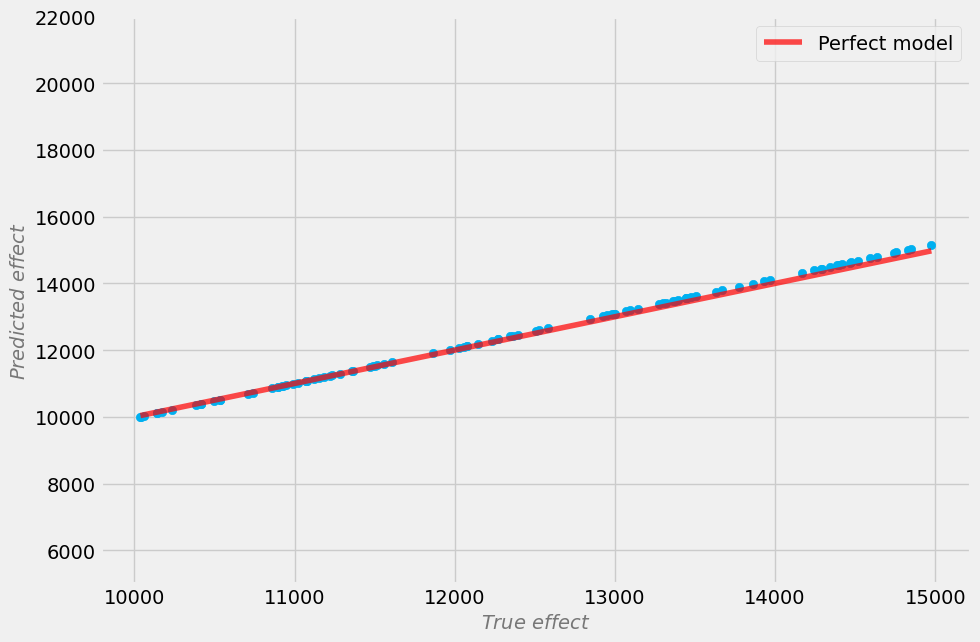

In [16]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)

앞서 정의한 `plot_effect` 함수를 호출하여, 테스트 데이터에 대한 실제 인과 효과와 모델이 예측한 인과 효과를 시각적으로 비교한다. x축은 실제 효과, y축은 예측된 효과를 나타내며, 점들이 대각선에 가까울수록 모델의 예측이 정확함을 의미한다.


### **1.5 비선형 DR**

`LinearDRLearner`가 최종 단계에서 처치 효과를 선형으로 모델링하는 반면, 일반적인 `DRLearner`는 이 최종 단계를 비선형 모델로 설정할 수 있다. 이를 통해 처치 효과가 공변량에 따라 복잡하고 비선형적인 관계를 가질 때, 즉 이질적 처치 효과(HTE)가 비선형적일 때 더 유연하고 정확한 추정이 가능하다. `model_final` 파라미터에 그래디언트 부스팅이나 신경망과 같은 비선형 모델을 지정함으로써 이러한 복잡한 관계를 포착할 수 있다.

In [17]:
# Get estimate (Doubly robust)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dr.DRLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'model_propensity': LogisticRegression(),
            'model_regression': LGBMRegressor(n_estimators=1000, max_depth=10),
            'model_final': LGBMRegressor(n_estimators=500, max_depth=10),
        },
        'fit_params': {}
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 289
[LightGBM] [Info] Number of data points in the train set: 2500, number of used features: 3
[LightGBM] [Info] Start training from score 143400.739600
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

`DRLearner`를 사용하여 이중 강건성 방법으로 인과 효과를 다시 추정한다. `LinearDRLearner`와 달리, `DRLearner`는 최종 효과를 추정하는 `model_final` 모델을 직접 지정할 수 있어 비선형적인 관계 포착이 가능하다. 여기서는 결과 모델(`model_regression`)과 최종 효과 모델(`model_final`) 모두에 강력한 비선형 모델인 `LGBMRegressor`를 사용하였으며, 성향 점수 모델(`model_propensity`)에는 `LogisticRegression`을 적용하였다.

In [18]:
# Compute predictions
effect_pred = estimate.estimator.effect(
    earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1)
)

# Get the true effect
effect_true = earnings_interaction_test['true_effect'].values

비선형 `DRLearner` 모델을 사용하여 테스트 데이터셋에 대한 인과 효과를 예측하고, 평가를 위해 실제 인과 효과 값을 별도로 추출한다.

In [19]:
# Compute the error
mean_absolute_percentage_error(effect_true, effect_pred)


비선형 `DRLearner` 모델의 예측값과 실제값 사이의 평균 절대 백분율 오차(MAPE)를 계산한다. 결과는 약 7.11%의 오차율을 보여준다.


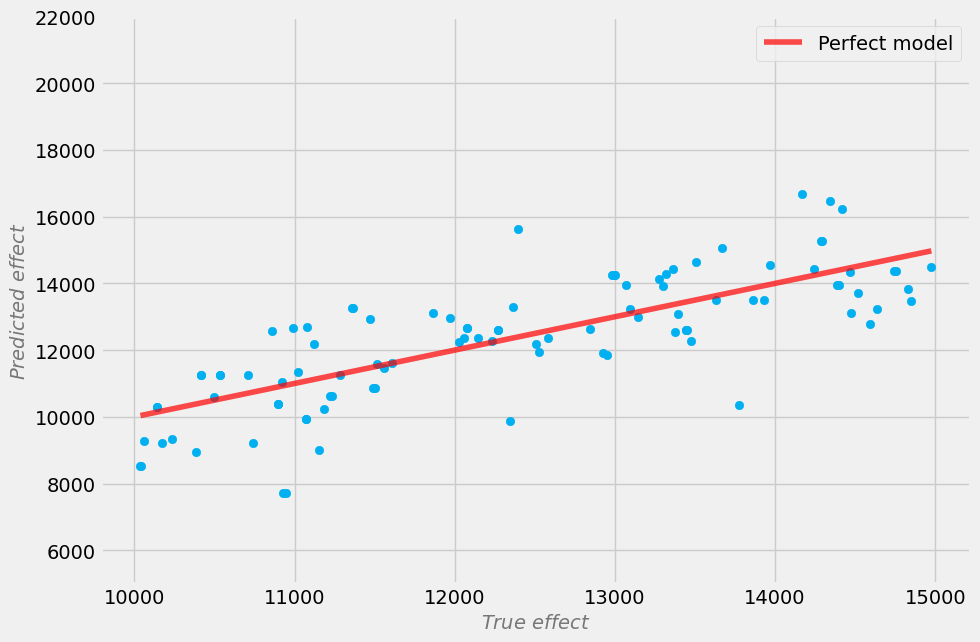

In [20]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)

`plot_effect` 함수를 사용하여 비선형 `DRLearner` 모델이 예측한 인과 효과와 실제 인과 효과를 산점도로 시각화하여 비교한다.


### **2. 이중 머신러닝 (Double Machine Learning, DML)**

이중 머신러닝(Double Machine Learning, DML)은 복잡한 환경에서 처치의 인과적 효과를 추정하기 위해 개발된 방법론이다. DML의 핵심 아이디어는 교란 변수의 영향을 효과적으로 제거하기 위해 직교화(orthogonalization) 개념을 사용하는 것이다. 이는 두 단계의 머신러닝 모델 학습을 통해 이루어진다.

1.  **1단계 (Nuisance Function Estimation)**:
      * 결과(Y)를 교란변수(W)로 예측하는 모델 `E[Y|W]`를 학습한다.
      * 처치(T)를 교란변수(W)로 예측하는 모델 `E[T|W]`를 학습한다.
2.  **2단계 (Causal Effect Estimation)**:
      * 1단계에서 얻은 예측을 사용하여 잔차(residual)를 계산한다: `Ỹ = Y - Ê[Y|W]` 와 `T̃ = T - Ê[T|W]`.
      * 이 두 잔차 간의 관계를 모델링하여(주로 선형 회귀) 최종적인 인과 효과를 추정한다.

이러한 잔차화 과정을 통해 교란 변수와 관련된 부분을 제거하고, 처치가 결과에 미치는 순수한 효과만을 분리해낼 수 있다. 또한, 교차 적합(cross-fitting) 기법을 함께 사용하여 머신러닝 모델의 과적합으로 인한 편향을 줄여준다.


### **2.1 인과 효과 추정**


In [21]:
# Get estimate (DML)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.LinearDML',
    target_units='ate',
    method_params={
        'init_params': {
            'model_y': LGBMRegressor(n_estimators=500, max_depth=10),
            'model_t': LogisticRegression(),
            'discrete_treatment': True
        },
        'fit_params': {}
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000221 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 2500, number of used features: 2
[LightGBM] [Info] Start training from score 143176.866000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

`EconML`의 `LinearDML` 모델을 사용하여 이중 머신러닝(DML) 방식으로 인과 효과를 추정한다. 이 모델은 내부적으로 두 개의 보조 모델을 사용한다. `model_y`는 결과(Y)를 공변량(W, X)으로 예측하는 회귀 모델이며, `model_t`는 처치(T)를 공변량으로 예측하는 모델이다. 여기서는 결과 모델로 `LGBMRegressor`를, 처치 모델로는 `LogisticRegression`을 사용하였다. `discrete_treatment=True`는 처치 변수가 이산형(범주형)임을 명시한다. `LinearDML`은 이 두 모델의 잔차를 이용한 최종 회귀 단계를 통해 선형적으로 이질적인 처치 효과를 추정한다.

In [22]:
estimate.cate_estimates.mean()


### **2.2 테스트 데이터에 대한 예측**


In [23]:
# Compute predictions
effect_pred = estimate.estimator.effect(earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1))

# Get the true effect
effect_true = earnings_interaction_test['true_effect'].values

학습된 `LinearDML` 추정기를 사용하여 테스트 데이터에 대한 인과 효과를 예측하고, 평가를 위해 실제 인과 효과 값을 추출한다.


In [24]:
# Compute the error
mean_absolute_percentage_error(effect_true, effect_pred)


`LinearDML` 모델의 테스트 데이터에 대한 예측 성능을 평균 절대 백분율 오차(MAPE)로 평가한다. 오차율은 약 0.453%로 매우 낮은 수준을 보여준다.

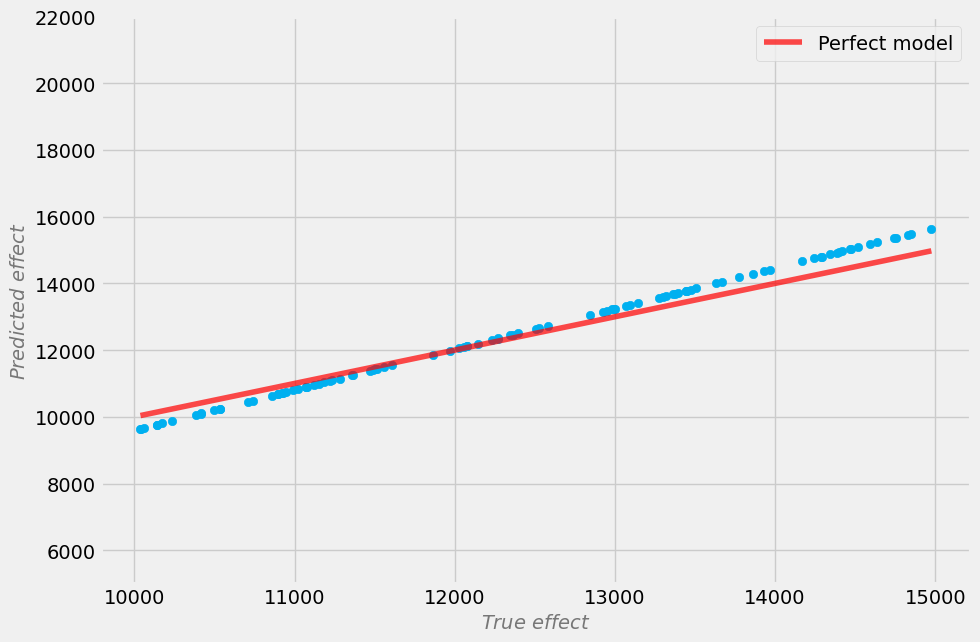

In [25]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)

`LinearDML` 모델이 테스트 데이터에 대해 예측한 인과 효과와 실제 인과 효과를 `plot_effect` 함수를 통해 시각적으로 비교한다.


### **2.3 더 많은 폴드를 사용한 DML**

이중 머신러닝(DML)에서는 교차 적합(cross-fitting) 또는 교차 폴드(cross-fold) 기법을 사용하여 모델의 과적합으로 인한 편향을 방지한다. 데이터를 여러 폴드(fold)로 나눈 뒤, 한 폴드는 효과 추정에 사용하고 나머지 폴드는 보조 함수(nuisance function) 학습에 사용하는 과정을 반복한다. 폴드의 수를 늘리면(예: 2-폴드에서 4-폴드로) 각 보조 함수를 학습시키는 데 더 많은 데이터를 사용할 수 있지만, 효과 추정에 사용되는 데이터는 줄어든다. 이처럼 폴드 수는 편향-분산 트레이드오프(bias-variance trade-off)에 영향을 미치므로, 적절한 값을 선택하는 것이 중요하다.


In [26]:
# Estimate the effect
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.LinearDML',
    target_units='ate',
    method_params={
        'init_params': {
            'model_y': LGBMRegressor(n_estimators=50, max_depth=10),
            'model_t': LogisticRegression(),
            'discrete_treatment': True,
            'cv': 4
        },
        'fit_params': {
        }
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000218 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 288
[LightGBM] [Info] Number of data points in the train set: 3750, number of used features: 2
[LightGBM] [Info] Start training from score 143075.447200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 3750, number of used features: 2
[LightGBM] [Info] Start training from score 143094.515467
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 3750, number of used features: 2
[LightGBM] [Info] Start tr

`LinearDML` 모델을 사용하여 인과 효과를 추정하되, 이번에는 교차 적합(cross-fitting)에 사용되는 폴드(fold)의 수를 4개로 설정한다(`cv=4`). 이는 데이터를 4개의 그룹으로 나누어 3개는 학습에, 1개는 예측에 사용하는 과정을 4번 반복하여 과적합을 방지하고 더 안정적인 추정치를 얻기 위함이다. 모델 학습 속도를 위해 `LGBMRegressor`의 `n_estimators`를 50으로 줄여 사용한다.

In [27]:
estimate.cate_estimates.mean()



4-폴드 교차 적합을 적용한 `LinearDML` 모델의 평균 처치 효과(ATE)를 계산한 결과, 약 12646.74로 나타났다.


In [28]:
# Compute predictions
effect_pred = estimate.estimator.effect(earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1))

# Get the true effect
effect_true = earnings_interaction_test['true_effect'].values

4-폴드 교차 적합으로 학습된 `LinearDML` 모델을 사용하여 테스트 데이터의 인과 효과를 예측하고, 실제 효과 값과 비교할 준비를 한다.


In [29]:
# Compute the error
mean_absolute_percentage_error(effect_true, effect_pred)



4-폴드 교차 적합을 사용한 `LinearDML` 모델의 테스트 데이터에 대한 MAPE를 계산한 결과, 약 1.01%의 오차율을 보였다.

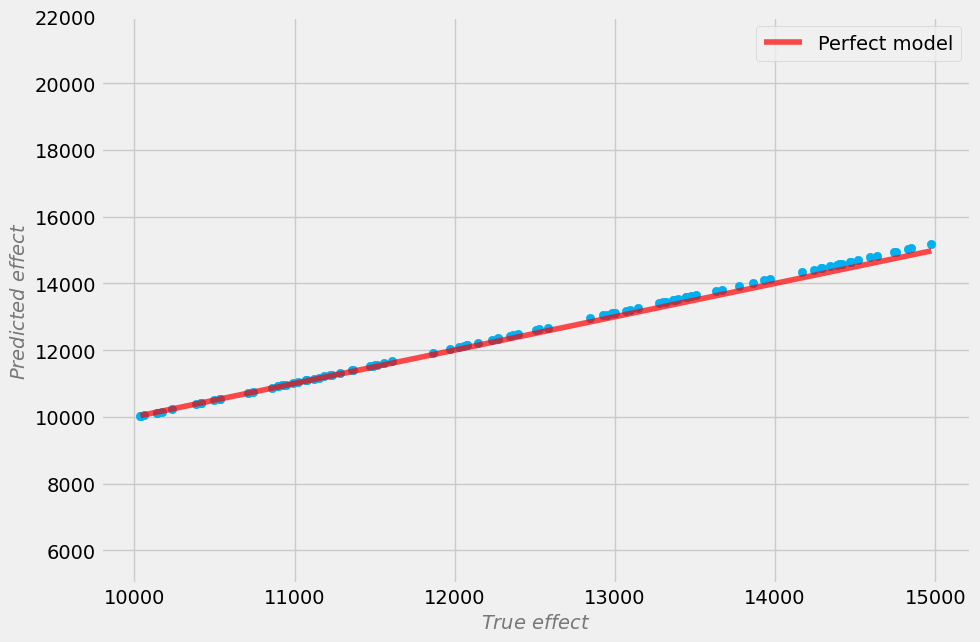

In [30]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)

4-폴드 교차 적합 모델의 테스트 데이터에 대한 예측 효과와 실제 효과를 산점도로 시각화하여 비교한다.


### **2.4 교차 검증을 사용한 DML**

모델의 성능을 더욱 향상시키고 안정적인 하이퍼파라미터를 찾기 위해, 이중 머신러닝(DML)의 보조 함수(nuisance function) 모델 자체를 교차 검증(Cross-Validation)을 통해 최적화할 수 있다. 예를 들어, `scikit-learn`의 `GridSearchCV`를 사용하여 결과 모델(`model_y`)과 처치 모델(`model_t`)에 대한 최적의 하이퍼파라미터 조합(예: `max_depth`, `n_estimators`)을 탐색한다. 이렇게 최적화된 모델들을 `LinearDML`의 보조 함수로 전달하면, DML 프레임워크 내에서 더욱 견고하고 정확한 인과 효과 추정이 가능하다.


In [31]:
# Define wrapped CV models
model_y = GridSearchCV(
    estimator=LGBMRegressor(),
    param_grid={
        'max_depth': [3, 10, 20, 100],
        'n_estimators': [10, 50, 100]
    }, cv=10, n_jobs=-1, scoring='neg_mean_squared_error'
)

model_t = GridSearchCV(
    estimator=LGBMClassifier(),
    param_grid={
        'max_depth': [3, 10, 20, 100],
        'n_estimators': [10, 50, 100]
    }, cv=10, n_jobs=-1, scoring='accuracy'
)

이중 머신러닝(DML)에 사용될 보조 모델들을 교차 검증을 통해 최적화하기 위해 `GridSearchCV` 객체를 생성한다.

  - `model_y`: 결과 모델로, `LGBMRegressor`의 `max_depth`와 `n_estimators` 하이퍼파라미터에 대한 최적 조합을 10-폴드 교차 검증과 음의 평균 제곱 오차(neg\_mean\_squared\_error)를 기준으로 탐색한다.
  - `model_t`: 처치 모델로, `LGBMClassifier`의 동일한 하이퍼파라미터들을 정확도(accuracy) 기준으로 최적화한다.

`n_jobs=-1`은 사용 가능한 모든 CPU 코어를 사용하여 탐색을 병렬로 수행하도록 설정한다.

-----

In [32]:
# Estimate the effect
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.LinearDML',
    target_units='ate',
    method_params={
        'init_params': {
            'model_y': model_y,
            'model_t': model_t,
            'discrete_treatment': True,
            'cv': 4
        },
        'fit_params': {
        }
    })

[LightGBM] [Info] Number of positive: 1477, number of negative: 2273
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.863065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 3750, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.393867 -> initscore=-0.431088
[LightGBM] [Info] Start training from score -0.431088
[LightGBM] [Info] Number of positive: 1477, number of negative: 2273
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.995884 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 3750, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.393867 -> initscore=-0.431088
[LightGBM] [Info] Start training from score -0.431088
[LightGBM] [Info] Numb

In [33]:
estimate.cate_estimates.mean()

In [34]:
# Compute predictions
effect_pred = estimate.estimator.effect(
    earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1)
)

# Get the true effect
effect_true = earnings_interaction_test['true_effect'].values

In [35]:
# Compute the error
mean_absolute_percentage_error(effect_true, effect_pred)

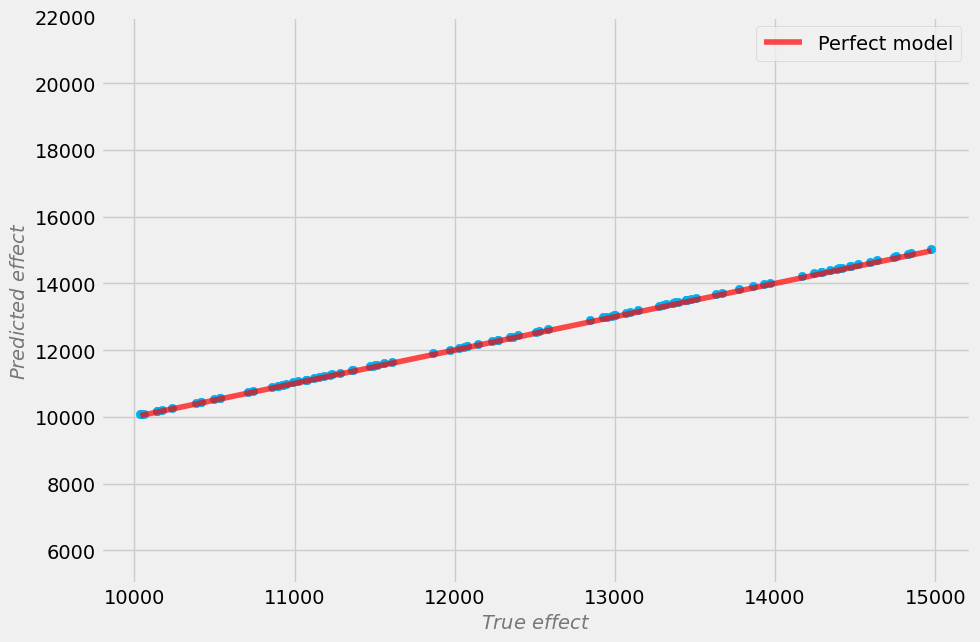

In [36]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)





## **3. 인과 포레스트 (Causal Forests)**


In [37]:
# Estimate the effect
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.CausalForestDML',
    target_units='ate',
    method_params={
        'init_params': {
            'model_y': LGBMRegressor(n_estimators=50, max_depth=10),
            'model_t': LGBMClassifier(n_estimators=50, max_depth=10),
            'discrete_treatment': True,
            'cv': 4
        },
        'fit_params': {
        }
    }
)

[LightGBM] [Info] Number of positive: 1476, number of negative: 2274
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 3750, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.393600 -> initscore=-0.432205
[LightGBM] [Info] Start training from score -0.432205
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [38]:
estimate.cate_estimates.mean()

In [39]:
# Compute predictions
effect_pred = estimate.estimator.effect(
    earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1)
)

# Get the true effect
effect_true = earnings_interaction_test['true_effect'].values

In [40]:
# Compute the error
mean_absolute_percentage_error(effect_true, effect_pred)

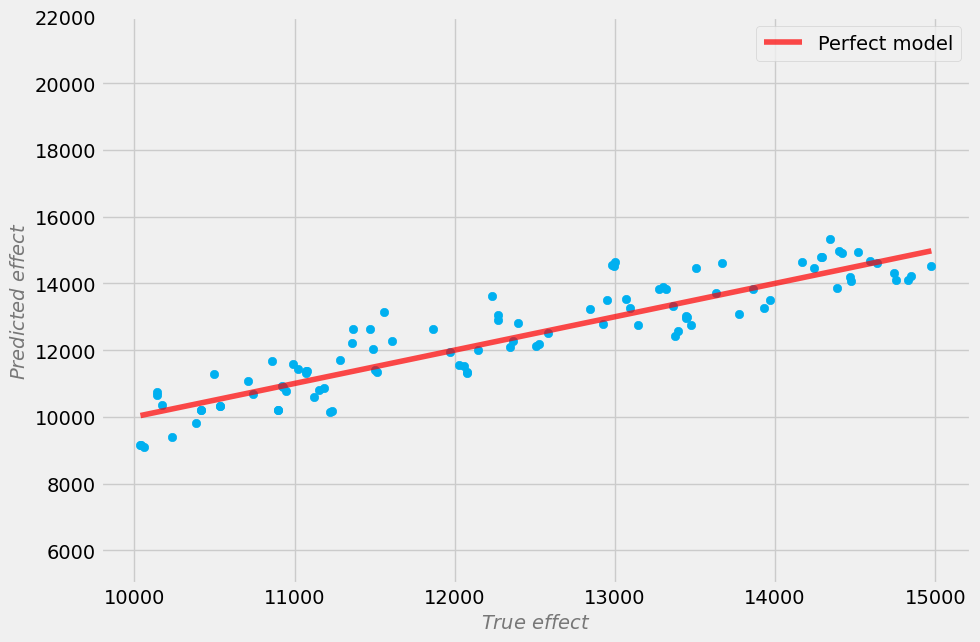

In [41]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)


## **4. 실험 데이터를 이용한 이질적 처치 효과(HTE) 분석**


In [44]:
# Read in the data
hillstrom_clean = pd.read_csv('./data/hillstrom_clean.csv')

# Read in labels mapping
with open(r'../data/hillstrom_clean_label_mapping.json', 'r') as f:
    hillstrom_labels_mapping = json.load(f)

In [45]:
hillstrom_clean.head()

,recency,history,mens,womens,newbie,visit,conversion,spend,zip_code__rural,zip_code__surburban,zip_code__urban,channel__multichannel,channel__phone,channel__web,treatment
0,10,142.44,1,0,0,0,0,0.0,0,1,0,0,1,0,1
1,6,329.08,1,1,1,0,0,0.0,1,0,0,0,0,1,0
2,7,180.65,0,1,1,0,0,0.0,0,1,0,0,0,1,1
3,9,675.83,1,0,1,0,0,0.0,1,0,0,0,0,1,2
4,2,45.34,1,0,0,0,0,0.0,0,0,1,0,0,1,1


In [46]:
# Drop redundant cols to avoid multicollinearity
hillstrom_clean = hillstrom_clean.drop(['zip_code__urban', 'channel__web'], axis=1)




### **4.1 탐색적 데이터 분석 (EDA)**

In [47]:
# Display mapping
hillstrom_labels_mapping

{'control': 0, 'womans_email': 1, 'mens_email': 2}

In [48]:
# P(visit)
hillstrom_clean.visit.mean()

In [49]:
# P(conversion)
hillstrom_clean.conversion.mean()

In [50]:
# Get sample size
sample_size = hillstrom_clean.shape[0]

In [51]:
# Check how random is the treatment assignment

# Split data
hillstrom_X = hillstrom_clean.drop(['visit', 'conversion', 'spend', 'treatment'], axis=1)
hillstrom_Y = hillstrom_clean['spend']
hillstrom_T = hillstrom_clean['treatment']

In [52]:
# P(T=t)
hillstrom_T.value_counts() / sample_size

treatment
1    0.334172
2    0.332922
0    0.332906
Name: count, dtype: float64

In [53]:
# Train-test split
X_train_eda, X_test_eda, T_train_eda, T_test_eda = train_test_split(hillstrom_X, hillstrom_T, test_size=.5)

In [54]:
# Split quality
T_test_eda.value_counts() / T_test_eda.shape[0]

treatment
1    0.334031
2    0.333344
0    0.332625
Name: count, dtype: float64

In [55]:
# Fit the EDA model
lgbm_eda = LGBMClassifier()
lgbm_eda.fit(X_train_eda, T_train_eda)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000988 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 282
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 9
[LightGBM] [Info] Start training from score -1.099050
[LightGBM] [Info] Start training from score -1.095679
[LightGBM] [Info] Start training from score -1.101115


LGBMClassifier()

In [56]:
# Get predictions on the test
T_pred_eda = lgbm_eda.predict(X_test_eda)

# Check accuracy
acc_eda = accuracy_score(T_test_eda, T_pred_eda)
acc_eda

In [57]:
# Generate random data
random_scores = []

test_eda_sample_size = T_test_eda.shape[0]

for i in range(10000):
    random_scores.append(
        (np.random.choice(
            [0, 1, 2],
            test_eda_sample_size) == np.random.choice(
            [0, 1, 2],
            test_eda_sample_size)).mean())

np.quantile(random_scores, .025), np.quantile(random_scores, .975)

In [60]:
# Get 95% CIs
lower = np.quantile(random_scores, .025)
upper = np.quantile(random_scores, .975)
lower, upper

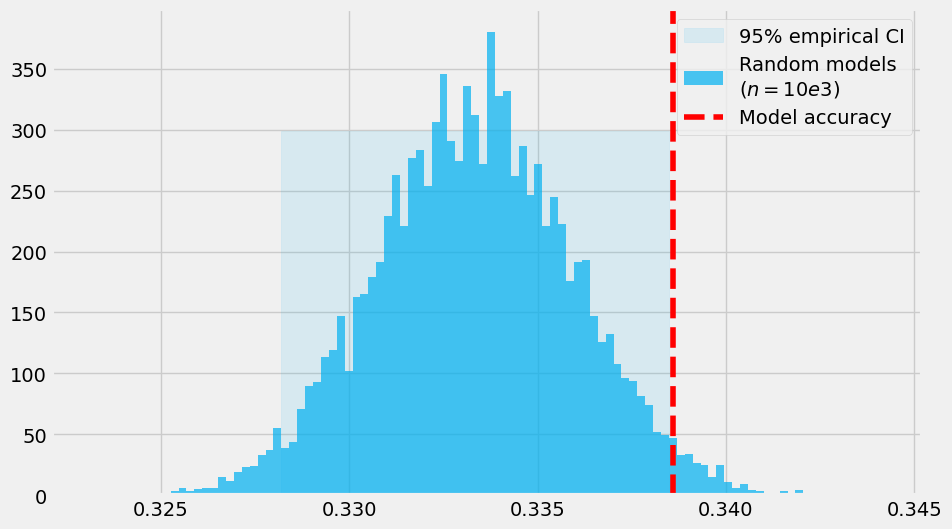

In [68]:
# Plot radom vs accuracy
plt.figure(figsize=(10, 6))
plt.fill_betweenx(
    x1=lower, 
    x2=upper, 
    y=np.arange(0, 300),
    color=COLORS[0],
    alpha=.1,
    label='95% empirical CI'
)
plt.hist(random_scores, alpha=.7, color=COLORS[0], bins=100, label='Random models\n($n=10e3$)')
plt.axvline(acc_eda, color=COLORS[1], ls='--', label='Model accuracy')

plt.legend()
plt.show()

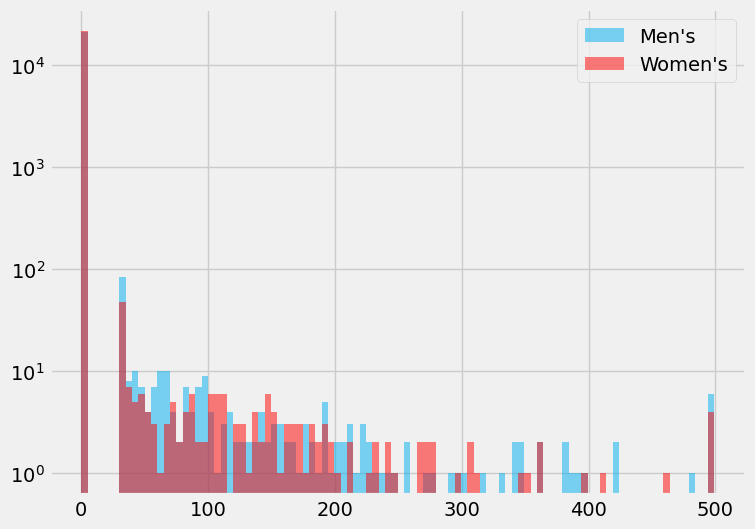

In [65]:
plt.figure(figsize=(8, 6))

plt.hist(
    hillstrom_clean[hillstrom_clean['treatment'] == 2]['spend'], 
    label=f'Men\'s', 
    color=COLORS[0],
    bins=100, 
    alpha=.5)

plt.hist(
    hillstrom_clean[hillstrom_clean['treatment'] == 1]['spend'], 
    label=f'Women\'s',
    color=COLORS[1],
    bins=100, 
    alpha=.5)

plt.legend()
plt.yscale('log')
plt.show()

In [66]:
# Outcome in the whole dataset
hillstrom_clean.groupby('treatment')['spend'].mean()

treatment
0    0.652789
1    1.077202
2    1.422617
Name: spend, dtype: float64

In [69]:
hillstrom_clean[hillstrom_clean['treatment'] == 1]['spend'].var()

In [70]:
hillstrom_labels_mapping

{'control': 0, 'womans_email': 1, 'mens_email': 2}

### **4.2 Hillstrom 데이터 모델링**

In [92]:
# No. of conversions
(hillstrom_Y[hillstrom_T > 0] > 0).sum()

456

In [93]:
# Train test split
X_train, X_test, y_train, y_test, T_train, T_test = train_test_split(
    hillstrom_X,
    hillstrom_Y,
    hillstrom_T,
    test_size=.5
)

In [94]:
# How many observations in train/test converted?
(y_train[T_train > 0] > 0).sum(), (y_test[T_test > 0] > 0).sum()

(215, 241)

In [95]:
def create_model(model_type, n_estimators=100, max_depth=10, learning_rate=.01):
    if model_type == 'regressor':
        return LGBMRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate)
    elif model_type == 'classifier':
        return LGBMClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate)
    else:
        raise NotImplementedError(f'Model type `{model_type}` not implemented.')

In [96]:
# Models
s_learner = SLearner(
    overall_model=create_model('regressor')
)

x_learner = XLearner(
    models=[
        create_model('regressor'),
        create_model('regressor'),
        create_model('regressor'),
    ],
    cate_models=[
        create_model('regressor'),
        create_model('regressor'),
        create_model('regressor'),
    ]
)

t_learner = TLearner(
    models=[
        create_model('regressor'),
        create_model('regressor'),
        create_model('regressor'),
    ]
)

dml = LinearDML(
    model_y=create_model('regressor'),
    model_t=create_model('classifier'),
    discrete_treatment=True,
    cv=5
)

dr = DRLearner(
    model_propensity=LogisticRegression(),
    model_regression=create_model('regressor'),
    model_final=create_model('regressor'),
    cv=5,
)

cf = CausalForestDML(
    model_y=create_model('regressor'),
    model_t=create_model('classifier'),
    discrete_treatment=True,
    cv=5
)

In [97]:
# Models
models = {
    'SLearner': s_learner,
    'TLearner': t_learner,
    'XLearner': x_learner,
    'DRLearner': dr,
    'LinearDML': dml,
    'CausalForestDML': cf
}

In [98]:
# Fit the estimator
for model_name, model in models.items():
    start = time.time()
    print(f'Fitting {model_name}')
    model.fit(
        Y=y_train,
        T=T_train,
        X=X_train
    )
    stop = time.time()

    print(f'{model_name} fitted in {stop - start:0.4f} seconds.\n')

Fitting SLearner
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 288
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 12
[LightGBM] [Info] Start training from score 1.109648
SLearner fitted in 0.1852 seconds.

Fitting TLearner
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041325 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 282
[LightGBM] [Info] Number of data points in the train set: 10705, number of used features: 9
[LightGBM] [Info] Start training from score 0.753475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `forc

In [99]:
# Compute effects
effects_train = {
    'treatment_1': {},
    'treatment_2': {}
}

effects_test = {
    'treatment_1': {},
    'treatment_2': {}
}


for treatment in [1, 2]:
    for model_name, model in tqdm(models.items()):

        # Compute effects on train
        effects_local_train = models[model_name].effect(X_train.values, T0=0, T1=treatment)
        effects_train[f'treatment_{treatment}'][model_name] = effects_local_train

        # Compute effects on test
        effects_local_test = models[model_name].effect(X_test.values, T0=0, T1=treatment)
        effects_test[f'treatment_{treatment}'][model_name] = effects_local_test

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]



### **4.3 십분위수별 업리프트 (Uplift by Decile)**

In [100]:
def get_uplift_by_decile(uplifts, t_true, t_pred, y_true):
    
    # Encapsulate the data & sort according to uplifts
    all_data = pd.DataFrame(
        dict(
            uplifts=uplifts, 
            y_true=y_true, 
            t_true=t_true)
    ).query(f't_true==0 | t_true=={t_pred}').sort_values('uplifts')
    
    # Partition into deciles
    all_data['deciles'] = pd.qcut(all_data['uplifts'], q=10, labels=np.arange(10), duplicates='raise')
    
    # Get mean responses within deciles
    mean_decile_resp = all_data.groupby(['deciles', 't_true']).mean()
    
    # Compute true decile uplift
    mean_decile_resp['true_uplift'] = mean_decile_resp['y_true'] * np.array([-1, 1]*10)
    true_uplift = mean_decile_resp.groupby(level=[0]).sum()['true_uplift']  
    
    return true_uplift[::-1]

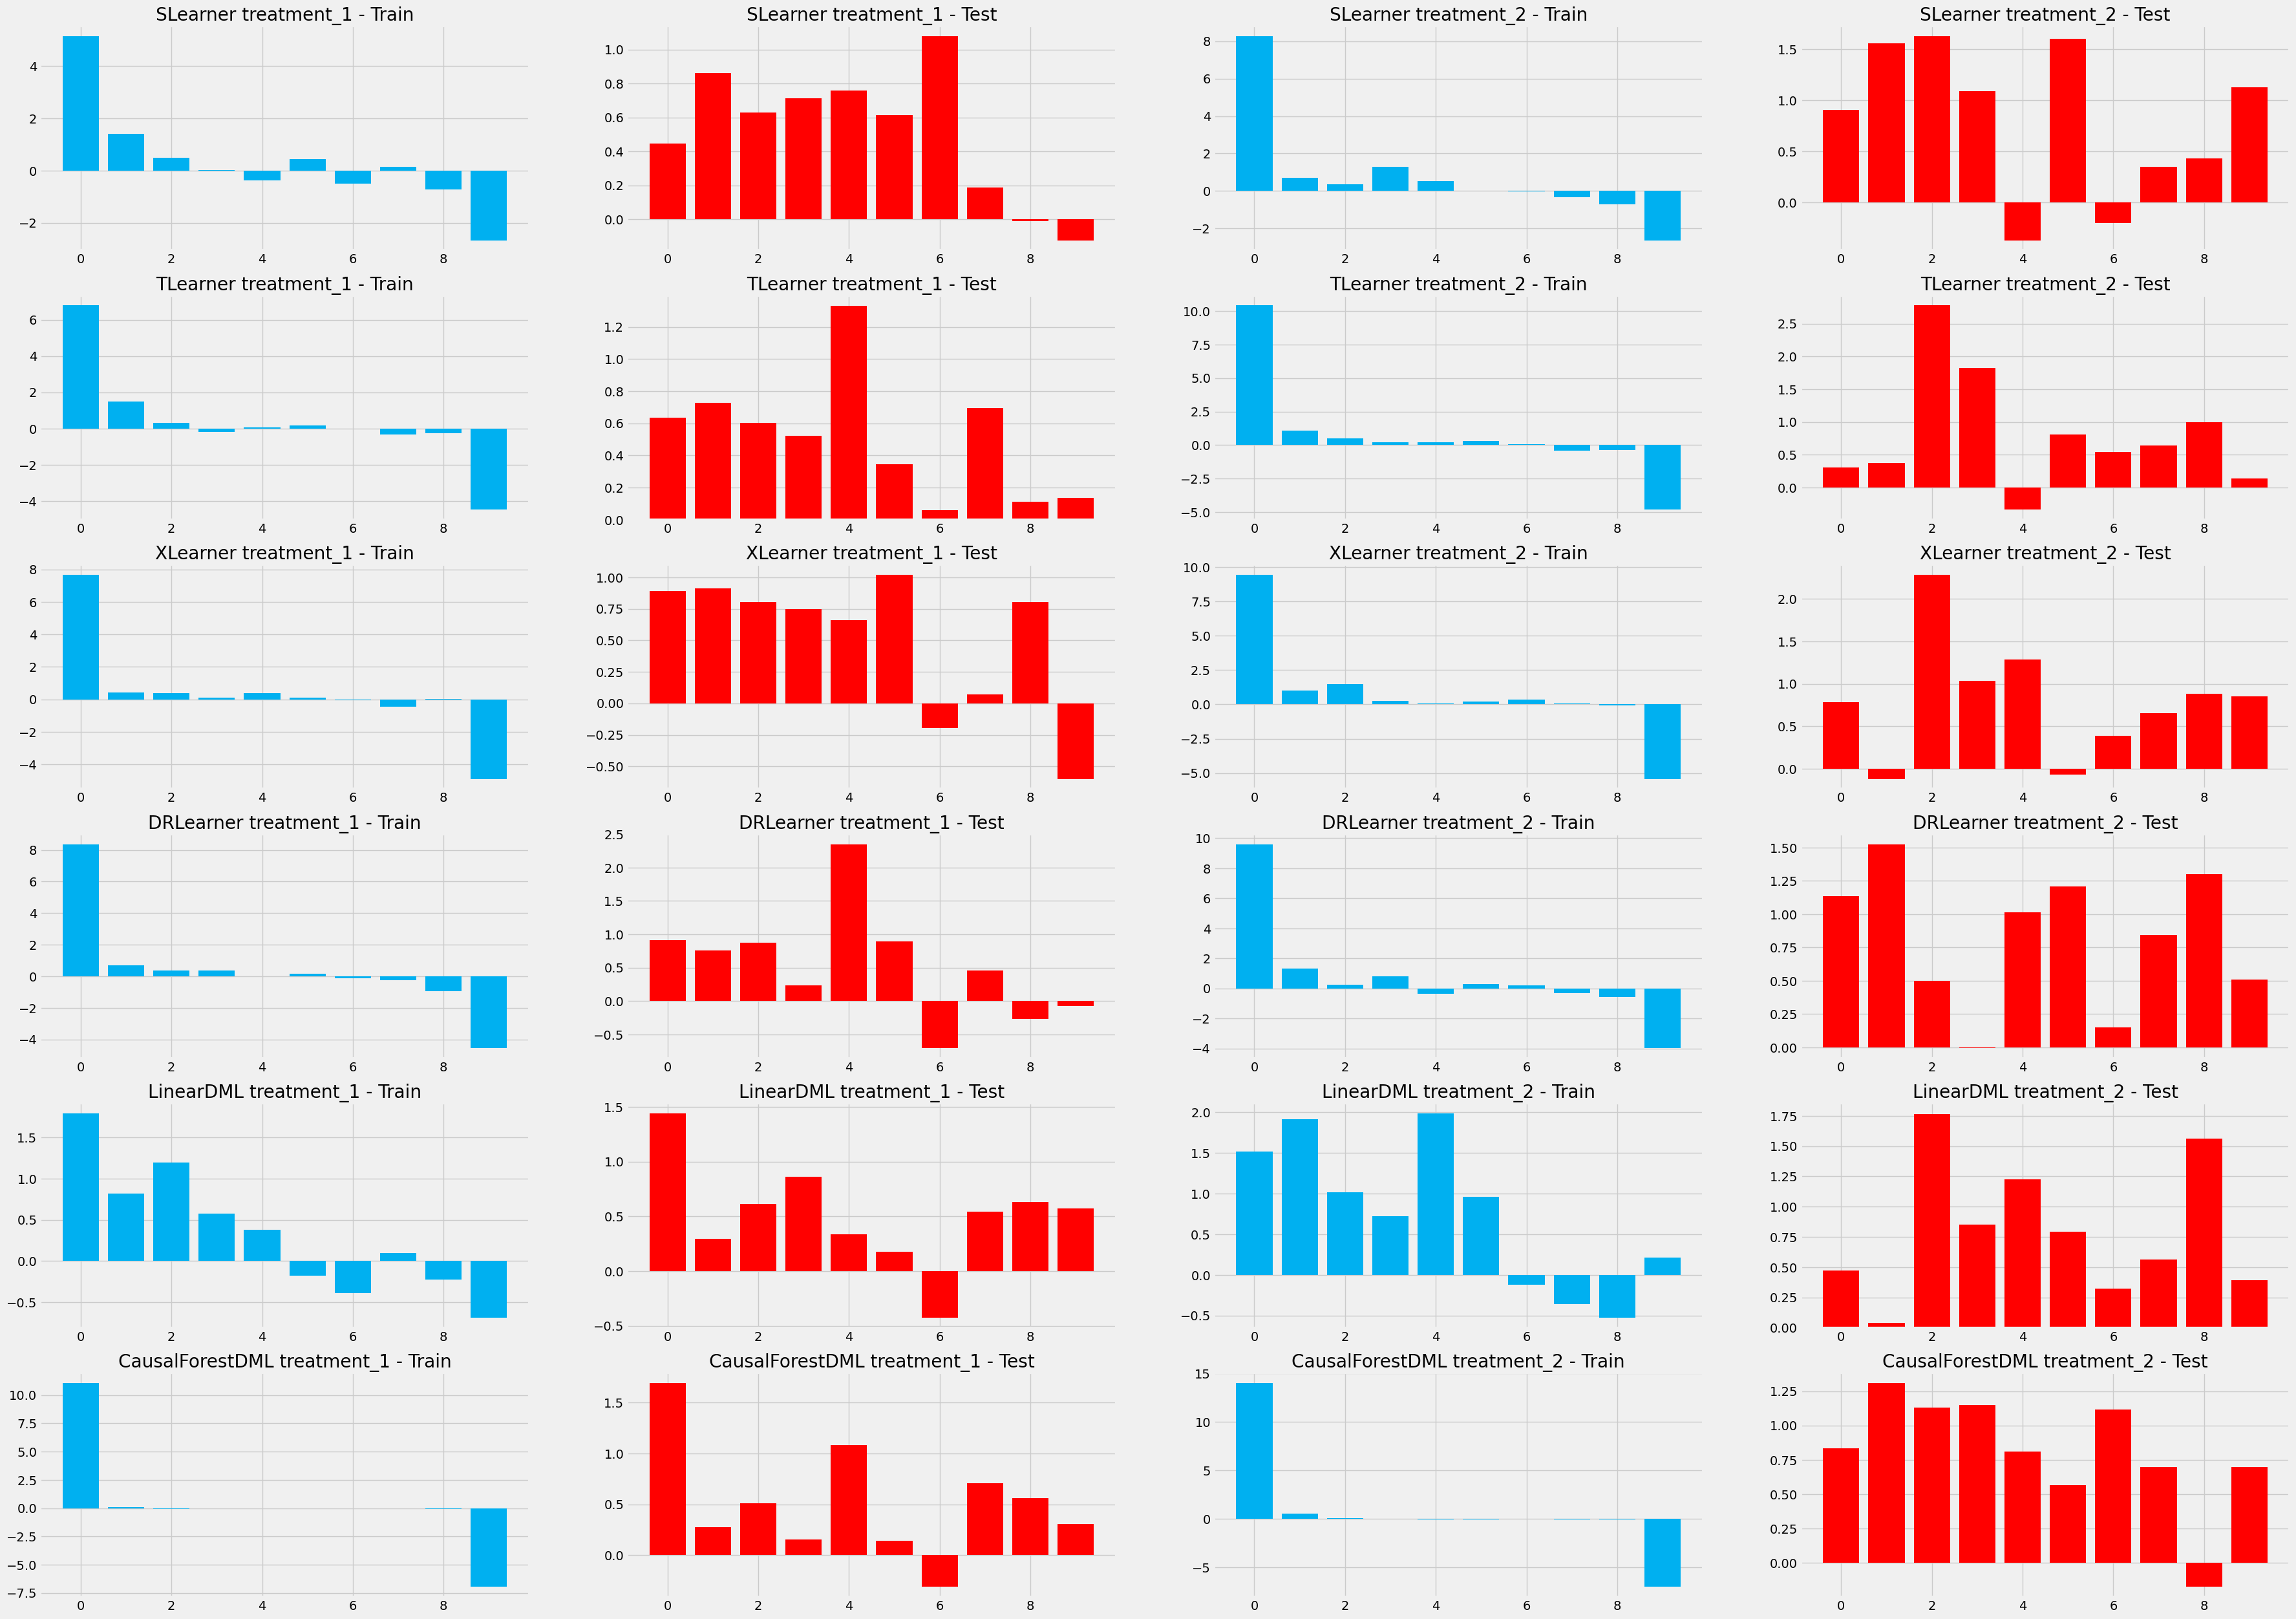

In [101]:
plt.figure(figsize=(40, 30))

i = 1

for model_name in models.keys():
    
    uplifts_by_decile = {
        'treatment_1': {},
        'treatment_2': {}
    }
    
    global_min = np.inf
    global_max = -np.inf
    
    for treatment in ['treatment_1', 'treatment_2']:

        uplift_by_decile_train = get_uplift_by_decile(
            uplifts=effects_train[treatment][model_name], 
            t_true=T_train,
            t_pred=int(treatment.split('_')[-1]),
            y_true=y_train
        )

        uplift_by_decile_test = get_uplift_by_decile(
            uplifts=effects_test[treatment][model_name], 
            t_true=T_test,
            t_pred=int(treatment.split('_')[-1]),
            y_true=y_test
        )
            
        plt.subplot(6, 4, i)
        plt.bar(np.arange(10), uplift_by_decile_train, color=COLORS[0])
        plt.title(f'{model_name} {treatment} - Train')
        
        plt.subplot(6, 4, i + 1)
        plt.bar(np.arange(10), uplift_by_decile_test, color=COLORS[1])
        plt.title(f'{model_name} {treatment} - Test')
        
        i += 2
        
plt.show()

### **4.4 기대 반응 (Expected Response)**



In [102]:
def get_effects_argmax(effects_arrays, return_matrix=False):
    """Returns argmax for each row of predicted effects for the arbitrary no. of treatments.

    :param effects_arrays: A list of arrays for K treatments, where K>=1 (without control null effects)
    :type effects_arrays: list of np.arrays

    :param return_matrix: Determines if the function returns a matrix of all effects
        (with added null effect for control)
    :type return_matrix: bool

    ...
    :return: A stacked matrix of all effects with added column for control effects (which is always 0)
    :rtype: np.array
    """

    n_rows = effects_arrays[0].shape[0]
    null_effect_array = np.zeros(n_rows)
    stacked = np.stack([null_effect_array] + effects_arrays).T

    if return_matrix:
        return np.argmax(stacked, axis=1), stacked

    return np.argmax(stacked, axis=1)


def get_expected_response(y_true, t_true, effects_argmax):
    """Computes the average expected response for an uplift model according to the formula
        proposed by:
        Zhao, Y., Fang, X., & Simchi-Levi, D. (2017). Uplift Modeling with Multiple Treatments and General Response Types.
        Proceedings of the 2017 SIAM International Conference on Data Mining, 588-596.
        Society for Industrial and Applied Mathematics.
    """

    proba_t = pd.Series(t_true).value_counts() / np.array(t_true).shape[0]
    treatments = proba_t.index.values

    z_vals = 0

    for treatment in treatments:
        h_indicator = effects_argmax == treatment
        t_indicator = t_true == treatment
        t_proba_local = proba_t[treatment]

        z_vals += (1/t_proba_local) * y_true * h_indicator * t_indicator

    return z_vals.mean()

In [103]:
# Compute expected response
print('Expecetd response on train:\n')
for model_name in models:
    effects_argmax = get_effects_argmax(
        [
            effects_train['treatment_1'][model_name],
            effects_train['treatment_2'][model_name]
        ]
    )

    expected_response = get_expected_response(
        y_true=y_train,
        t_true=T_train,
        effects_argmax=effects_argmax
    )

    print(f'{model_name}: {expected_response}')

print('\n' + '-'*30)

print('Expected response on test:\n')
for model_name in models:
    effects_argmax = get_effects_argmax(
        [
            effects_test['treatment_1'][model_name],
            effects_test['treatment_2'][model_name]
        ]
    )

    expected_response = get_expected_response(
        y_true=y_test,
        t_true=T_test,
        effects_argmax=effects_argmax
    )

    print(f'{model_name}: {expected_response}')

Expecetd response on train:

SLearner: 2.258449636033046
TLearner: 2.64853559232306
XLearner: 2.5862138873912044
DRLearner: 2.5892535170953677
LinearDML: 1.6395591947765198
CausalForestDML: 3.191967586557131

------------------------------
Expected response on test:

SLearner: 1.3219106901557172
TLearner: 1.2657057958977411
XLearner: 1.2821103422537992
DRLearner: 1.386582039723567
LinearDML: 1.3363019154816749
CausalForestDML: 1.2706936872142123


In [104]:
# Outcome in the whole dataset
hillstrom_clean.groupby('treatment')['spend'].mean()

treatment
0    0.652789
1    1.077202
2    1.422617
Name: spend, dtype: float64

### 4.5 Confidence intervals신뢰 구간


In [105]:
models['LinearDML'].effect_interval(X=X_test, T0=0, T1=1)

(array([-0.92490516, -0.75263148, -0.8041704 , ..., -0.99563092,
        -0.56309916, -0.16937476]),
 array([1.39262751, 1.77725704, 1.55075676, ..., 0.9186196 , 1.05086868,
        2.23002453]))

In [106]:
models['LinearDML'].effect_interval(X=X_test.iloc[0:1, :], T0=0, T1=1)

(array([-0.92490516]), array([1.39262751]))

In [107]:
# CIs (DML)
ints = np.stack(models['LinearDML'].effect_interval(X=X_test, T0=0, T1=1, alpha=.05)).T

# What % of effects contains zero?
(np.sign(ints[:, 0]) == np.sign(ints[:, 1])).sum() / ints.shape[0]